<a href="https://colab.research.google.com/github/PihuCodeTech/Aircraft-Engine-RUL-Prediction/blob/main/notebooks/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

══════════════════════════════════════════════════════════════════════
  VARIANCE TABLE (std after MinMax normalization)
══════════════════════════════════════════════════════════════════════

  Feature          FD001       FD002       FD003       FD004     Min_std        Status
  ────────────────────────────────────────────────────────────────────
  op1            0.1257      0.3511      0.1275      0.3519       0.1257   ✅ KEEP (op)
  op2            0.2442      0.3682      0.2262      0.3690       0.2262   ✅ KEEP (op)
  op3            0.0000      0.3559      0.0000      0.3563       0.0000   ✅ KEEP (op)
  s1             0.0000      0.3582      0.0000      0.3589       0.0000     ⚠️  MIXED
  s2             0.1506      0.3421      0.1225      0.3428       0.1225        ✅ KEEP
  s3             0.1337      0.2870      0.1333      0.2867       0.1333        ✅ KEEP
  s4             0.1519      0.2867      0.1525      0.2866       0.1519        ✅ KEEP
  s5             0.0000      0.3374     

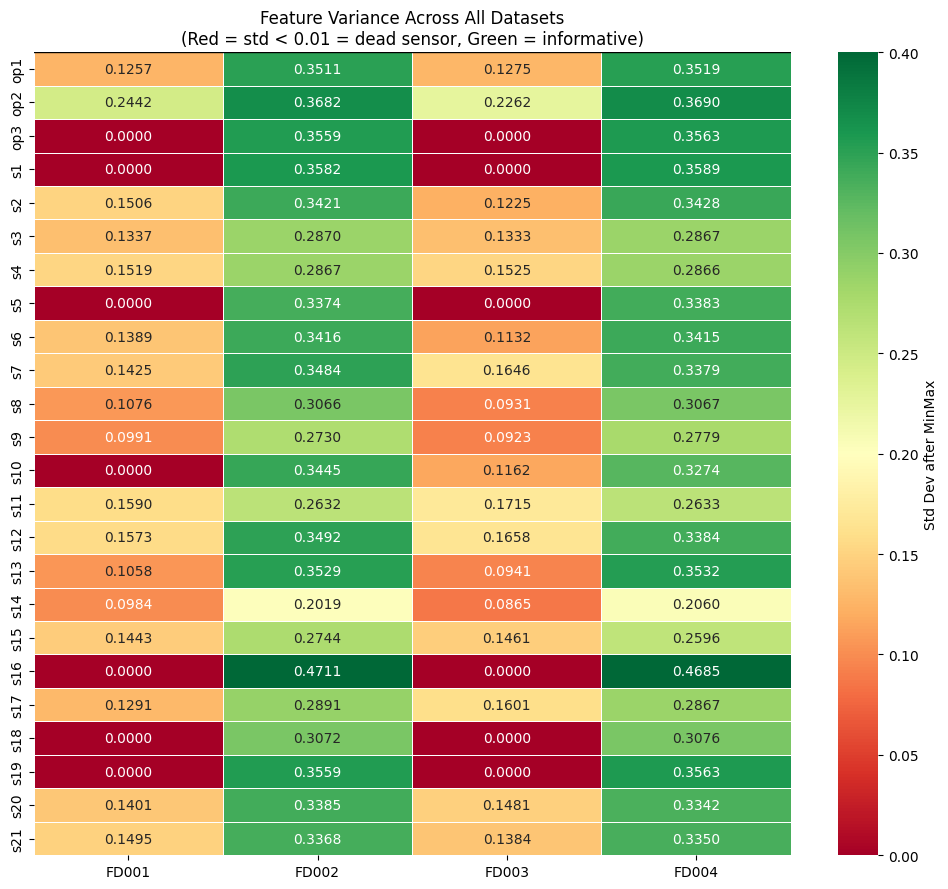

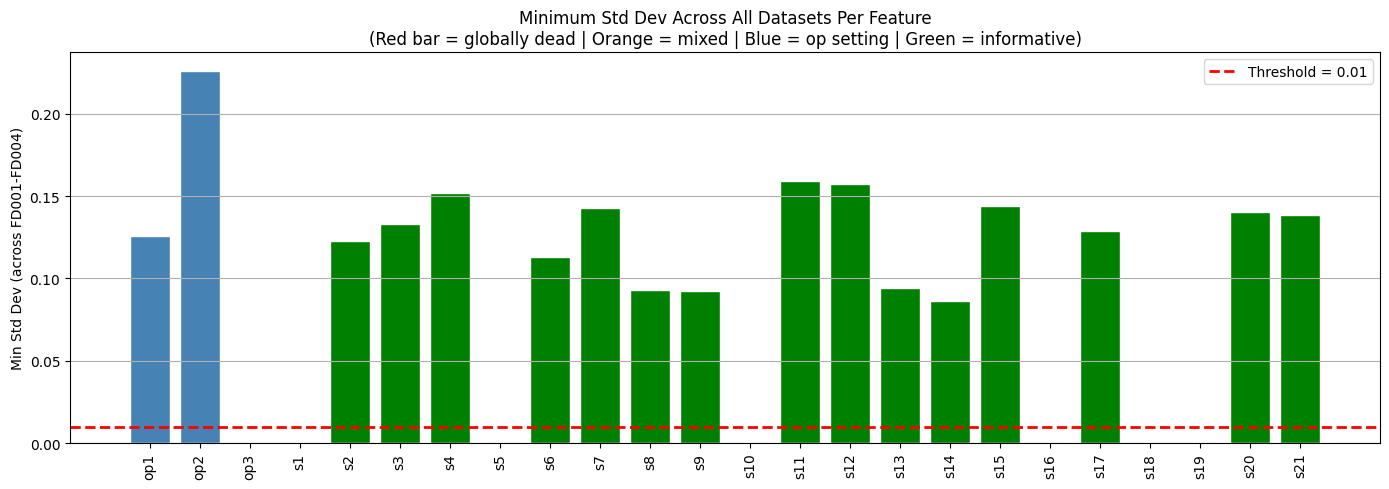

══════════════════════════════════════════════════════════════════════
  FEATURE SETS FOR EXPERIMENTS
══════════════════════════════════════════════════════════════════════

  Set A — Full (24 features):
  ['op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

  Set B — Variance filtered (24 features):
  ['op1', 'op2', 'op3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']

  Dropped in Set B: []

  Next steps:
  1. Train BiLSTM with Set A → record RMSE
  2. Train BiLSTM with Set B → record RMSE
  3. If Set B <= Set A: use variance filtered set
  4. If Set B >  Set A: keep all features
  5. Same comparison for TCN



In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# VARIANCE-BASED FEATURE SELECTION
# Goal: identify globally dead sensors across all 4 datasets
# Strategy: variance threshold only — no correlation filtering
# ══════════════════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

DATA_PATH = '/content/'
cols      = ['id','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
DATASETS  = ['FD001','FD002','FD003','FD004']

# All features to analyze (keep op settings always)
sensor_cols = [f's{i}' for i in range(1,22)]
op_cols     = ['op1','op2','op3']
all_feat    = op_cols + sensor_cols   # cycle excluded — not a sensor

VAR_THRESHOLD = 0.01   # after MinMax normalization

# ══════════════════════════════════════════════════════════════════════════════
# Compute variance per feature per dataset
# ══════════════════════════════════════════════════════════════════════════════
variance_table = {}

for ds in DATASETS:
    df = pd.read_csv(f"{DATA_PATH}train_{ds}.txt", sep=r"\s+", header=None)
    df.columns = cols

    # Normalize before computing variance
    scaler = MinMaxScaler()
    df_norm = df.copy()
    df_norm[all_feat] = scaler.fit_transform(df[all_feat])

    stds = df_norm[all_feat].std()
    variance_table[ds] = stds

var_df = pd.DataFrame(variance_table)   # shape: features × datasets

# ══════════════════════════════════════════════════════════════════════════════
# Print variance table
# ══════════════════════════════════════════════════════════════════════════════
print("═"*70)
print("  VARIANCE TABLE (std after MinMax normalization)")
print("═"*70)
print(f"\n  {'Feature':<10}", end='')
for ds in DATASETS:
    print(f"  {ds:>10}", end='')
print(f"  {'Min_std':>10}  {'Status':>12}")
print("  " + "─"*68)

global_keep = []
global_drop = []
inconsistent = []

for feat in all_feat:
    row     = var_df.loc[feat]
    min_std = row.min()
    max_std = row.max()

    # Dead in ALL datasets → global drop
    all_dead = all(row < VAR_THRESHOLD)
    # Alive in ALL datasets → global keep
    all_alive = all(row >= VAR_THRESHOLD)
    # Mixed → inconsistent
    mixed = not all_dead and not all_alive

    if feat in op_cols:
        status = "✅ KEEP (op)"
        global_keep.append(feat)
    elif all_dead:
        status = "❌ DEAD"
        global_drop.append(feat)
    elif all_alive:
        status = "✅ KEEP"
        global_keep.append(feat)
    else:
        status = "⚠️  MIXED"
        inconsistent.append(feat)

    print(f"  {feat:<10}", end='')
    for ds in DATASETS:
        val   = var_df.loc[feat, ds]
        color = "" if val >= VAR_THRESHOLD else " *"
        print(f"  {val:>9.4f}{color[0] if color else ' '}", end='')
    print(f"  {min_std:>10.4f}  {status:>12}")

# ══════════════════════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'═'*70}")
print(f"  SUMMARY")
print(f"{'═'*70}")
print(f"\n  Global KEEP  ({len(global_keep)}): {global_keep}")
print(f"  Global DROP  ({len(global_drop)}): {global_drop}")
print(f"  MIXED/CHECK  ({len(inconsistent)}): {inconsistent}")

print(f"""
  Decision rules applied:
    op1, op2, op3  → ALWAYS KEEP (condition identifiers)
    std < {VAR_THRESHOLD} in ALL datasets → GLOBAL DROP (physically dead)
    std < {VAR_THRESHOLD} in SOME datasets → MIXED (review manually)
    std >= {VAR_THRESHOLD} in ALL datasets → GLOBAL KEEP
""")

# ══════════════════════════════════════════════════════════════════════════════
# Heatmap — variance across all datasets
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 9))
mask = pd.DataFrame(False, index=var_df.index, columns=var_df.columns)

# Annotate with actual values
sns.heatmap(var_df, annot=True, fmt='.4f', cmap='RdYlGn',
            vmin=0, vmax=0.4,
            linewidths=0.5,
            cbar_kws={'label': 'Std Dev after MinMax'})

# Mark threshold line
plt.axhline(y=0, color='black', linewidth=1)
plt.title(f'Feature Variance Across All Datasets\n'
          f'(Red = std < {VAR_THRESHOLD} = dead sensor, '
          f'Green = informative)')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Bar chart: min variance across datasets per feature
# ══════════════════════════════════════════════════════════════════════════════
min_std_per_feat = var_df.min(axis=1)
colors = []
for feat in all_feat:
    if feat in op_cols:
        colors.append('steelblue')
    elif feat in global_drop:
        colors.append('red')
    elif feat in inconsistent:
        colors.append('orange')
    else:
        colors.append('green')

plt.figure(figsize=(14, 5))
bars = plt.bar(all_feat, min_std_per_feat, color=colors, edgecolor='white')
plt.axhline(VAR_THRESHOLD, color='red', linestyle='--',
            linewidth=2, label=f'Threshold = {VAR_THRESHOLD}')
plt.xticks(rotation=90)
plt.title('Minimum Std Dev Across All Datasets Per Feature\n'
          '(Red bar = globally dead | Orange = mixed | '
          'Blue = op setting | Green = informative)')
plt.ylabel('Min Std Dev (across FD001-FD004)')
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# Final feature sets to test
# ══════════════════════════════════════════════════════════════════════════════
full_feature_set     = all_feat
variance_feature_set = [f for f in all_feat if f not in global_drop]

print(f"{'═'*70}")
print(f"  FEATURE SETS FOR EXPERIMENTS")
print(f"{'═'*70}")
print(f"\n  Set A — Full ({len(full_feature_set)} features):")
print(f"  {full_feature_set}")
print(f"\n  Set B — Variance filtered ({len(variance_feature_set)} features):")
print(f"  {variance_feature_set}")
print(f"\n  Dropped in Set B: {global_drop}")
print(f"""
  Next steps:
  1. Train BiLSTM with Set A → record RMSE
  2. Train BiLSTM with Set B → record RMSE
  3. If Set B <= Set A: use variance filtered set
  4. If Set B >  Set A: keep all features
  5. Same comparison for TCN
""")